In [19]:
import torch
from torchvision.io import decode_image, ImageReadMode
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights, fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

from b200_lego_dataset import load_val_set
from presets import get_transforms

device = torch.device('cpu')

### Load Model

In [20]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

num_classes = 201
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# 3. Load your trained weights
checkpoint = torch.load('lego_model_final.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Inference

In [3]:
val_set = load_val_set()

In [4]:
image, target = val_set[0]
image = image.to(device)
targets = {k : v.to(device) if isinstance(v, torch.Tensor) else v for k,v in target.items()}

In [25]:
def perform_inference(image_path, model, device, threshold=0.2):
    # 1. Load and Preprocess the image
    img = decode_image(image_path, mode=ImageReadMode.RGB)
    transform = get_transforms(is_train=False)
    img_tensor = transform(img).to(device)

    # 2. Run Inference
    with torch.no_grad():
        # Model expects a list of images
        prediction = model([img_tensor])

    pred = prediction[0]

    print(pred)
    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    mask = scores > threshold
    boxes = boxes[mask]
    labels = labels[mask]

    plt.figure(figsize=(12, 8))
    plt.imshow(img.permute(1, 2, 0))
    ax = plt.gca()

    for box, label, score in zip(boxes, labels, scores[mask]):
        xmin, ymin, xmax, ymax = box
        # Create a rectangle patch
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        # Label with score
        plt.text(xmin, ymin, f"ID: {label} ({score:.2f})",
                 verticalalignment='top', color='white',
                 bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})

    plt.axis('off')
    plt.show()

{'boxes': tensor([[489.1743, 106.8362, 577.0275, 154.0962],
        [520.6041, 228.5271, 593.6213, 281.9825],
        [ 79.4802, 542.8549, 136.3915, 593.9782],
        [224.6790, 454.0320, 296.8865, 502.9727],
        [323.2096, 370.4171, 356.7132, 403.1918],
        [563.0095, 308.8899, 609.2787, 348.8866],
        [ 42.5119, 299.1357,  77.9220, 354.1016],
        [434.7589, 562.3558, 466.7323, 607.4291],
        [104.0017, 509.6054, 147.2375, 551.2292],
        [239.4419, 456.2417, 292.2171, 504.1478],
        [484.8198, 147.1475, 536.4787, 218.5079],
        [223.0326, 450.7407, 253.1598, 496.2998],
        [450.6093, 284.3897, 477.0378, 310.7580],
        [ 77.8359, 545.7273, 133.0059, 595.5126],
        [484.2933, 147.0782, 535.4150, 222.5465],
        [220.1148, 455.6592, 260.6942, 500.4137],
        [430.1288, 448.8232, 493.5974, 489.3687],
        [104.9806, 507.2932, 145.0565, 552.9869],
        [426.8661, 449.1782, 495.6028, 493.7215],
        [108.5030, 144.8421, 147.5055, 1

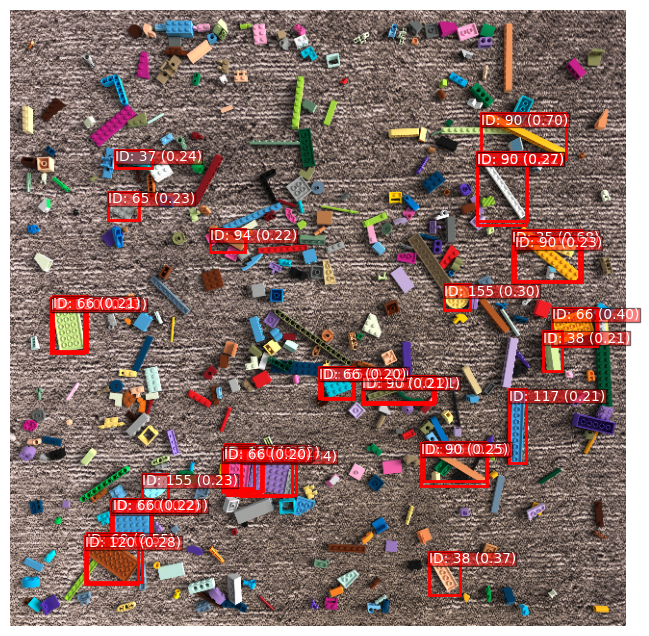

In [26]:
perform_inference('data/train/images/500.png', model, device)